# Data Quality Audit

This notebook focuses exclusively on assessing data quality for the
American Express Campus Challenge dataset.

The objective is to identify missing values, inconsistencies, and
potential data issues. No cleaning, imputation, or modeling is performed
in this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.figsize"]=(10, 5)
sns.set_style("whitegrid")

In [2]:
PROJECT_ROOT=Path.cwd().parent
DATA_DIR=PROJECT_ROOT/"data"
DATA_PATH=DATA_DIR/"amex_data.csv"
assert DATA_PATH.exists(), "Invalid data path"

In [5]:
df=pd.read_csv(DATA_PATH)

In [16]:
df.head(10)

,customer_id,offer_id,event_ts,event_dt,offer_action,var_1,var_2,var_3,var_4,var_5,...,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50
0,1010494,601711,2023-11-01 10:25:21.000904,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.089583,0.083204,2151.0,0.0,0.0,0.0,0.0,0.0,True,0.0
1,1010494,33452,2023-11-09 08:37:35.165000,2023-11-09 00:00:00,0,NaN,NaN,NaN,NaN,NaN,...,0.111752,0.181776,1668.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1010494,88456737,2023-11-01 10:15:55.000489,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.088514,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1010494,390981,2023-11-01 10:27:27.000313,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.086931,0.059246,3678.0,0.0,False,0.0,0.0,0.0,1.0,0.0
4,1010494,7114,2023-11-09 08:37:38.553000,2023-11-09 00:00:00,0,NaN,NaN,NaN,NaN,NaN,...,0.089497,0.124221,3619.0,0.0,0.0,0.0,False,0.0,1.0,0.0
5,1010494,72053,2023-11-09 09:44:33.159000,2023-11-09 00:00:00,0,NaN,NaN,NaN,NaN,NaN,...,0.204255,0.201718,1905.0,0.0,0.0,False,False,0.0,1.0,0.0
6,1010494,6919527,2023-11-01 10:23:22.000379,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.074321,NaN,NaN,0.0,False,0.0,False,0.0,1.0,0.0
7,1010494,60142,09 Nov 2023 08:37,2023-11-09 00:00:00,0,NaN,NaN,NaN,NaN,NaN,...,0.144743,0.375323,696.0,0.0,0.0,0.0,0.0,0.0,True,0.0
8,1010494,55716,2023-11-01 10:26:33.000808,2023-11-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,...,0.068832,0.063888,3735.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,1010494,404258283,2023-11-09 16:39:55.026000,2023-11-09 00:00:00,0,NaN,NaN,NaN,NaN,NaN,...,0.070122,0.124421,4306.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [18]:
df.info()
total_rows=df.shape[0]
print(total_rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004812 entries, 0 to 2004811
Data columns (total 55 columns):
 #   Column        Dtype  
---  ------        -----  
 0   customer_id   int64  
 1   offer_id      int64  
 2   event_ts      object 
 3   event_dt      object 
 4   offer_action  object 
 5   var_1         float64
 6   var_2         float64
 7   var_3         float64
 8   var_4         float64
 9   var_5         float64
 10  var_6         float64
 11  var_7         float64
 12  var_8         float64
 13  var_9         float64
 14  var_10        float64
 15  var_11        float64
 16  var_12        float64
 17  var_13        float64
 18  var_14        float64
 19  var_15        float64
 20  var_16        float64
 21  var_17        float64
 22  var_18        float64
 23  var_19        float64
 24  var_20        float64
 25  var_21        float64
 26  var_22        float64
 27  var_23        float64
 28  var_24        float64
 29  var_25        float64
 30  var_26        floa

In [12]:
df.describe()

,customer_id,offer_id,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_48
count,2.004812e+06,2.004812e+06,769235.000000,939953.000000,295718.000000,198259.000000,1.443714e+06,1.674323e+06,1.125559e+06,1.437420e+06,...,27275.000000,1.286100e+06,2.004759e+06,1.857870e+06,1.857870e+06,1.678014e+06,1.846806e+06,1.846806e+06,2004759.0,2.004759e+06
mean,1.465379e+06,2.020622e+07,33.973431,32.409650,33.640363,40.631689,3.438814e+01,3.770162e+01,3.613842e+01,3.649525e+01,...,12.835197,2.730998e-01,9.571012e+01,7.011631e+03,9.357645e+04,1.175265e-01,1.181813e-01,3.258467e+03,0.0,7.507137e-02
std,2.594202e+05,9.972241e+07,22.039018,20.558765,24.717924,28.877784,2.151217e+01,1.955954e+01,2.261652e+01,2.120697e+01,...,17.266552,1.658929e-01,5.228714e+01,3.399906e+03,5.284505e+04,9.326043e-02,9.600510e-02,1.062592e+03,0.0,2.635065e-01
min,1.000125e+06,1.185000e+03,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,-33.000000,2.500000e-02,3.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.964834e-02,1.000000e+00,0.0,0.000000e+00
25%,1.249353e+06,6.768100e+04,13.000000,19.000000,13.000000,22.000000,1.800000e+01,2.500000e+01,2.000000e+01,2.000000e+01,...,20.000000,2.000000e-01,6.000000e+01,4.482000e+03,4.067200e+04,7.826103e-02,7.333775e-02,2.932000e+03,0.0,0.000000e+00
50%,1.467485e+06,9.671300e+04,34.000000,31.000000,31.000000,40.000000,3.400000e+01,3.700000e+01,3.500000e+01,3.600000e+01,...,20.000000,2.000000e-01,9.100000e+01,7.662000e+03,1.086210e+05,9.042495e-02,9.285426e-02,3.458000e+03,0.0,0.000000e+00
75%,1.692897e+06,6.358690e+05,46.000000,44.000000,47.000000,64.000000,4.500000e+01,4.700000e+01,4.700000e+01,4.700000e+01,...,23.000000,3.000000e-01,1.220000e+02,9.079000e+03,1.432130e+05,1.147157e-01,1.287612e-01,3.957000e+03,0.0,0.000000e+00
max,1.910509e+06,8.766658e+08,100.000000,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,...,33.000000,2.000000e+00,1.357000e+03,3.510200e+04,1.763500e+05,1.000000e+00,1.000000e+00,5.704000e+03,0.0,1.000000e+00


Only columns CUSTOMER_ID and OFFER_ID have the same number of rows as total_rows; other columns not reliable for boolean masking in DF.

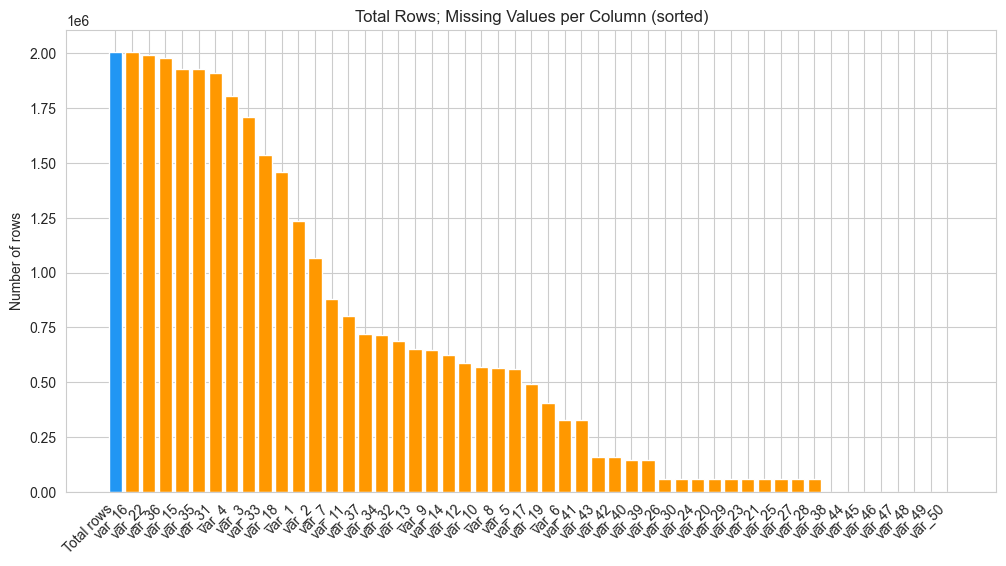

In [37]:
missing_val_per_col=df.isna().sum()
missing_val_per_col=missing_val_per_col[missing_val_per_col>0]
missing_val_per_col=missing_val_per_col.sort_values(ascending=False)
labels_bar_graph=["Total rows"]+list(missing_val_per_col.index)
values_bar_graph=[total_rows]+list(missing_val_per_col.values)
plt.figure(figsize=(12,6))
plt.bar(labels_bar_graph, values_bar_graph, color=["#2196F3"] + ["#FF9800"]*len(missing_val_per_col))
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of rows")
plt.title("Total Rows, Missing Values per Column (sorted)")
plt.show()

Some columns have missing data almost equal to total rows; add noise, force ugly imputation. We must resolve this first.

In [59]:
missing_ratio=df.isna().mean().sort_values(ascending=False)
missing_ratio.head(15)

var_16    0.999318
var_22    0.994180
var_36    0.986395
var_15    0.961038
var_35    0.960922
var_31    0.952411
var_4     0.901108
var_3     0.852496
var_33    0.765586
var_18    0.726822
var_1     0.616306
var_2     0.531152
var_7     0.438571
var_11    0.401283
var_37    0.358493
dtype: float64

We need to drop columns with high missing ratios while at the same time maintaining data integrity and need to check the effects of this cleaning beforehand to make an informed decision. This will reduce noise and increase efficiency.

This notebook DOES NOT handle cleaning.

In [72]:
present_values_per_col=df.notna().sum()
present_values_per_col.head(50)
print(present_values_per_col.sum())

78947559


In [73]:
deletion_thresholds=np.arange(0.5,1,0.01)
information_loss=[]
for i in deletion_thresholds:
    deletable_values=present_values_per_col[missing_ratio>i]
    loss=deletable_values.sum()/present_values_per_col.sum()
    information_loss.append(loss)


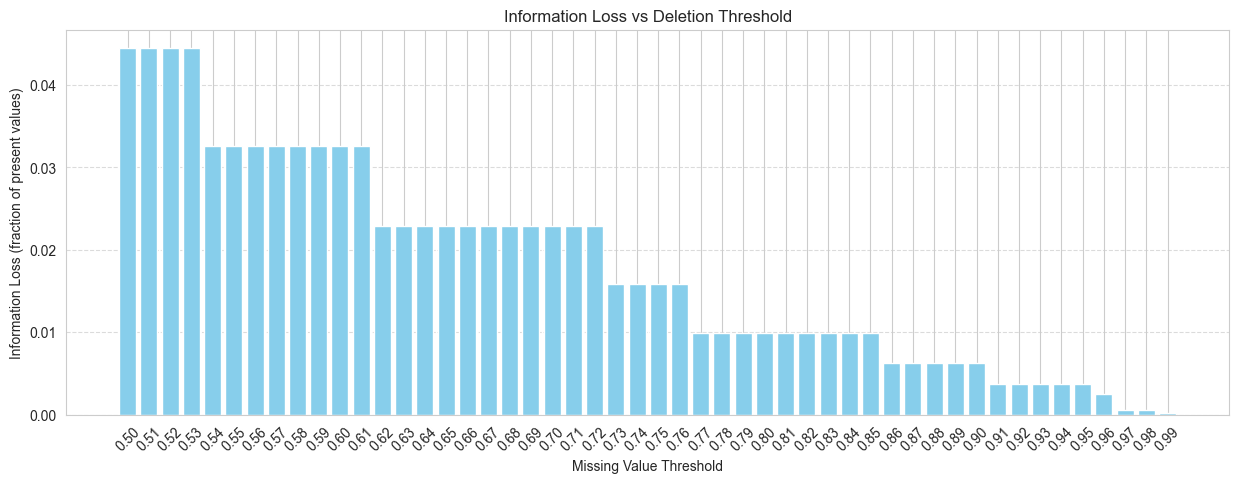

In [74]:
plt.figure(figsize=(15,5))
plt.bar([f"{t:.2f}" for t in deletion_thresholds], information_loss, color='skyblue')
plt.xlabel("Missing Value Threshold")
plt.ylabel("Information Loss (fraction of present values)")
plt.title("Information Loss vs Deletion Threshold")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


For each threshold T, we consider columns with missing_ration>T as droppable to calculate information_loss. The graph is consistent with our expectations: Information Loss decreases strictly as T increases.

In [93]:
row_missing_ratio_per_col = df.isna().mean(axis=1)
row_missing_ratio_per_col.describe()

count    2.004812e+06
mean     2.740520e-01
std      8.999456e-02
min      1.052632e-01
25%      2.105263e-01
50%      2.631579e-01
75%      3.157895e-01
max      7.192982e-01
dtype: float64

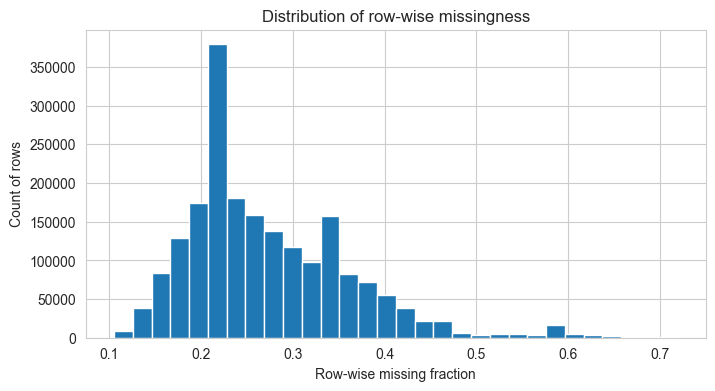

In [94]:
plt.figure(figsize=(8,4))
plt.hist(row_missing_ratio_per_col, bins=30)
plt.xlabel("Row-wise missing fraction")
plt.ylabel("Count of rows")
plt.title("Distribution of row-wise missingness")
plt.show()


Most rows are partially incomplete.

A typical row is missing ~25-30% of its data.

MISSINGNESS IS ROW-WISE SYSTEMATIC, NOT CATASTROPHIC.

Dropping rows due to missing value will lead to massive data loss and data quality also degrades.

Column deletion appears the safer option for now.

In [84]:
df.duplicated().sum()

np.int64(17166)

Are duplicates exact across time? If yes then ingestion bug likely.

Are duplicates legitimate repeated events?

Are duplicates tied to missingness?
